In [4]:
import pandas as pd
import numpy as np

sentiment = pd.read_csv(r'C:\Users\DELL\Downloads\fear_greed_index.csv')
trades = pd.read_csv(r'C:\Users\DELL\Downloads\historical_data.csv')

print(sentiment.shape, trades.shape)
print(sentiment.isnull().sum())
print(trades.isnull().sum())
print(trades.duplicated().sum())

(2644, 4) (211224, 16)
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
0


In [8]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.strftime('%Y-%m-%d')
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.strftime('%Y-%m-%d')

sentiment['sentiment'] = sentiment['classification'].str.strip().replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed',
    'Neutral': 'Greed'
})

df = trades.merge(sentiment[['date', 'sentiment']], on='date', how='left')

print(df.shape)
print(df['sentiment'].value_counts())
print(df['sentiment'].isnull().sum())

(211224, 18)
sentiment
Greed    127981
Fear      83237
Name: count, dtype: int64
6


In [10]:
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])

In [14]:
print(df['Side'].unique())

['BUY' 'SELL']


In [16]:
ls_ratio = df.groupby(['sentiment', 'Side']).size().unstack(fill_value=0)
ls_ratio['ls_ratio'] = ls_ratio['BUY'] / (ls_ratio['SELL'] + 1)

trade_freq = df.groupby(['date', 'sentiment']).size().reset_index(name='trade_count')

print(trader_profile.describe())
print("\nBUY/SELL ratio by sentiment:")
print(ls_ratio)
print("\nAvg trades per day by sentiment:")
print(trade_freq.groupby('sentiment')['trade_count'].mean())

          total_pnl   win_rate   trade_count  avg_size_usd
count  3.200000e+01  32.000000     32.000000     32.000000
mean   3.217800e+05   0.403063   6600.750000   6007.929370
std    4.948276e+05   0.108498   8250.373724   7281.058575
min   -1.676211e+05   0.234987    332.000000    507.626933
25%    4.689324e+04   0.329562   1381.750000   2011.069878
50%    1.176551e+05   0.391968   3699.000000   3327.972048
75%    4.063941e+05   0.452963   8862.500000   7375.525018
max    2.143383e+06   0.810876  40184.000000  34396.580284

BUY/SELL ratio by sentiment:
Side         BUY   SELL  ls_ratio
sentiment                        
Fear       41205  42032  0.980301
Greed      61491  66496  0.924718

Avg trades per day by sentiment:
sentiment
Fear     792.733333
Greed    341.298667
Name: trade_count, dtype: float64


In [18]:
print(df.groupby('sentiment')['Closed PnL'].agg(['mean', 'median', 'std']))

print(daily_pnl.groupby('sentiment')['Closed PnL'].agg(['mean', 'median', 'std']))

print(df.groupby('sentiment')['win'].mean())

                mean  median         std
sentiment                               
Fear       49.212077     0.0  990.875398
Greed      48.447837     0.0  869.362720
                  mean      median           std
sentiment                                       
Fear       5185.146443  122.737038  31224.148764
Greed      3997.867991  245.444960  26874.836788
sentiment
Fear     0.407871
Greed    0.413472
Name: win, dtype: float64


In [22]:
# Segment 1: High vs Low trade frequency
trader_profile['freq_segment'] = pd.qcut(trader_profile['trade_count'], 
    q=3, labels=['Rare', 'Moderate', 'Frequent'])

# Segment 2: Winners vs Losers
trader_profile['perf_segment'] = pd.cut(trader_profile['win_rate'],
    bins=[0, 0.4, 0.6, 1.0], labels=['Loser', 'Neutral', 'Winner'])

# Segment 3: High vs Low avg trade size
trader_profile['size_segment'] = pd.qcut(trader_profile['avg_size_usd'],
    q=3, labels=['Small', 'Mid', 'Large'])

# Merge segments back to main df
df = df.merge(trader_profile[['Account','freq_segment','perf_segment','size_segment']], 
              on='Account', how='left')

# PnL by segment
print("PnL by frequency segment:")
print(trader_profile.groupby('freq_segment')['total_pnl'].mean())

print("\nPnL by performance segment:")
print(trader_profile.groupby('perf_segment')[['total_pnl','trade_count']].mean())

print("\nPnL by size segment:")
print(trader_profile.groupby('size_segment')['total_pnl'].mean())

PnL by frequency segment:
freq_segment
Rare        159708.161616
Moderate    265813.464157
Frequent    534730.411281
Name: total_pnl, dtype: float64

PnL by performance segment:
                  total_pnl  trade_count
perf_segment                            
Loser         346799.665467  5549.812500
Neutral       291271.259284  7502.266667
Winner        379095.406711  9893.000000

PnL by size segment:
size_segment
Small    150523.524452
Mid      432511.985925
Large    392370.937747
Name: total_pnl, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_25552\1547157681.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(trader_profile.groupby('freq_segment')['total_pnl'].mean())
C:\Users\DELL\AppData\Local\Temp\ipykernel_25552\1547157681.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(trader_profile.groupby('perf_segment')[['total_pnl','trade_count']].mean())
C:\Users\DELL\AppData\Local\Temp\ipykernel_25552\1547157681.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observe

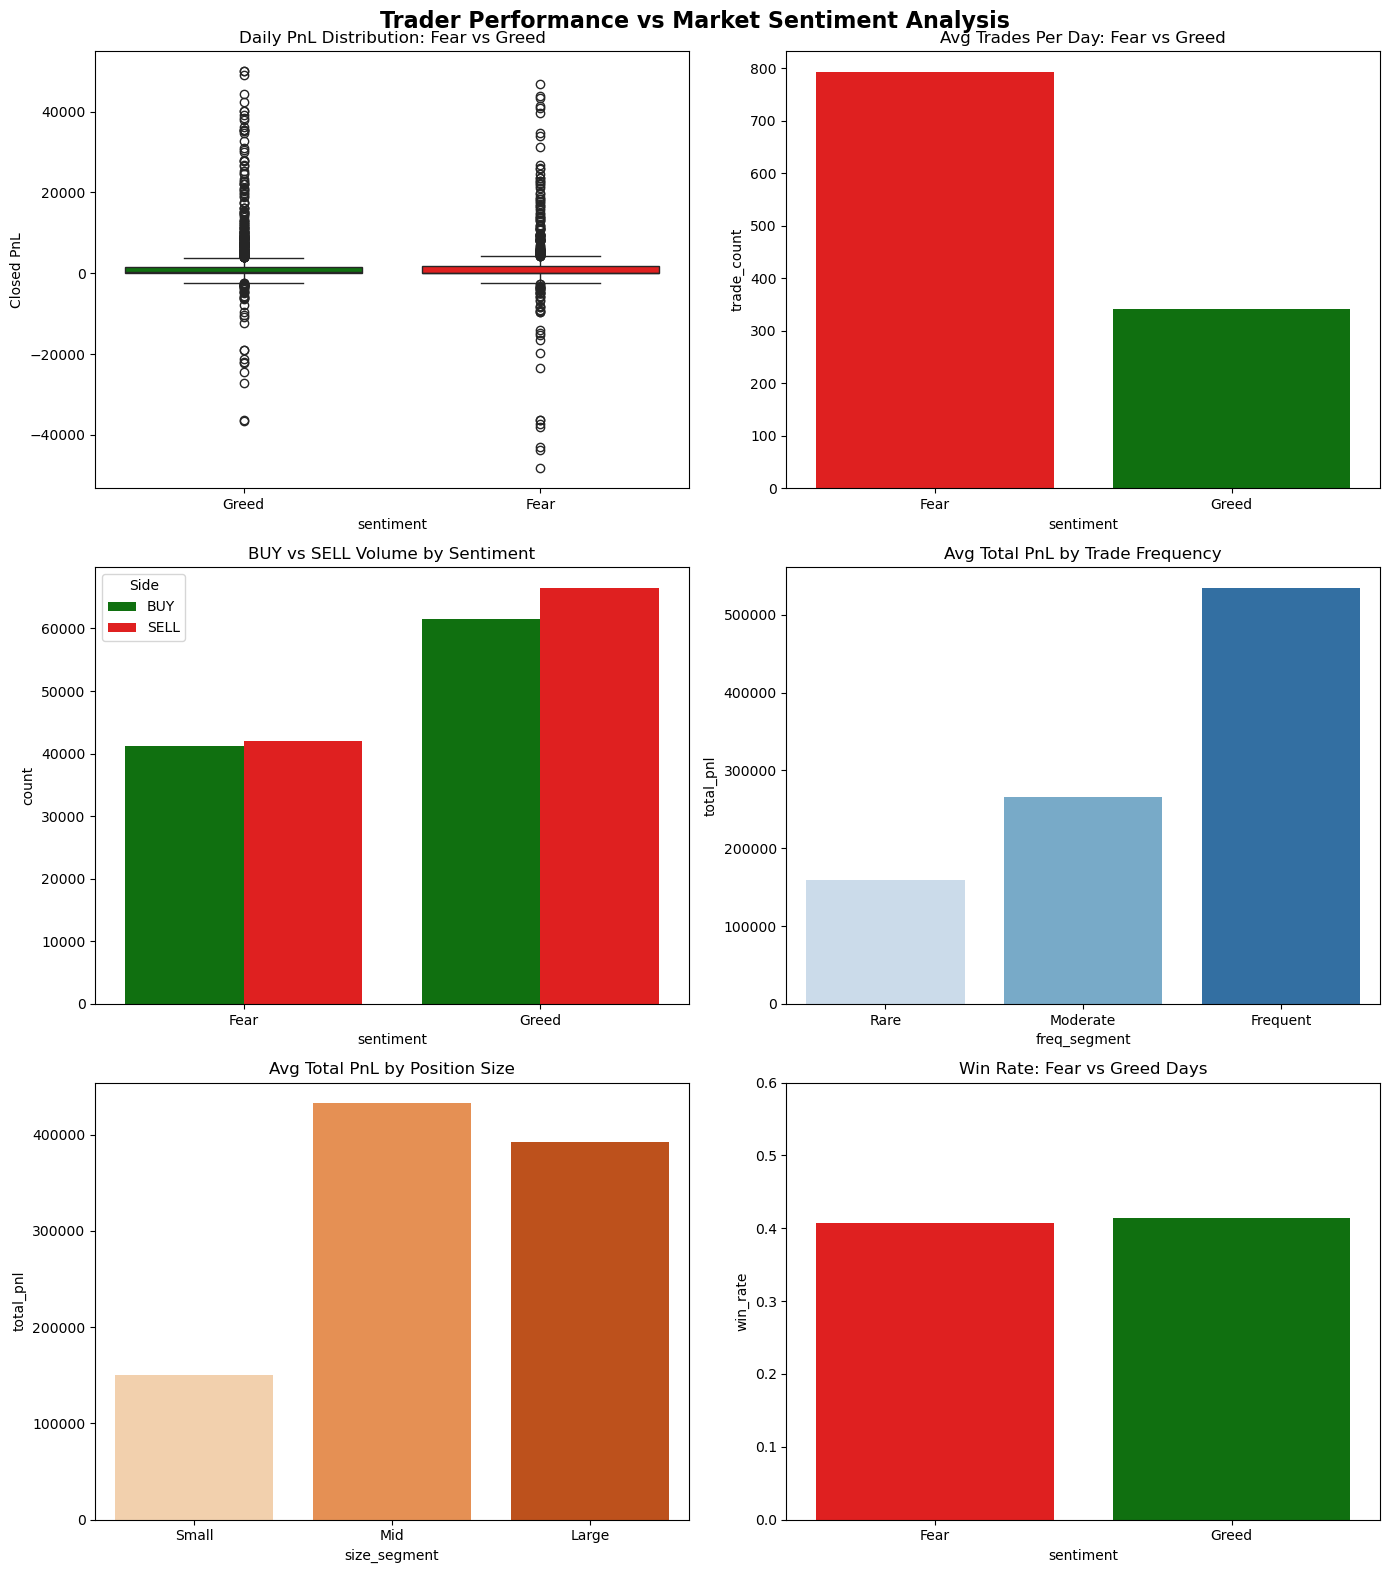

Charts saved cleanly!


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('charts', exist_ok=True)

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('Trader Performance vs Market Sentiment Analysis', fontsize=16, fontweight='bold')

# Chart 1: PnL distribution Fear vs Greed
sns.boxplot(data=daily_pnl[daily_pnl['Closed PnL'].between(-50000, 50000)],
            x='sentiment', y='Closed PnL', ax=axes[0,0],
            hue='sentiment', legend=False, palette={'Fear':'red','Greed':'green'})
axes[0,0].set_title('Daily PnL Distribution: Fear vs Greed')

# Chart 2: Avg trades per day by sentiment
trade_avg = trade_freq.groupby('sentiment')['trade_count'].mean().reset_index()
sns.barplot(data=trade_avg, x='sentiment', y='trade_count', ax=axes[0,1],
            hue='sentiment', legend=False, palette={'Fear':'red','Greed':'green'})
axes[0,1].set_title('Avg Trades Per Day: Fear vs Greed')

# Chart 3: BUY vs SELL by sentiment
ls_plot = df.groupby(['sentiment','Side']).size().reset_index(name='count')
sns.barplot(data=ls_plot, x='sentiment', y='count', hue='Side', ax=axes[1,0],
            palette={'BUY':'green','SELL':'red'})
axes[1,0].set_title('BUY vs SELL Volume by Sentiment')

# Chart 4: PnL by frequency segment
freq_pnl = trader_profile.groupby('freq_segment', observed=True)['total_pnl'].mean().reset_index()
sns.barplot(data=freq_pnl, x='freq_segment', y='total_pnl', ax=axes[1,1],
            hue='freq_segment', legend=False, palette='Blues')
axes[1,1].set_title('Avg Total PnL by Trade Frequency')

# Chart 5: PnL by size segment
size_pnl = trader_profile.groupby('size_segment', observed=True)['total_pnl'].mean().reset_index()
sns.barplot(data=size_pnl, x='size_segment', y='total_pnl', ax=axes[2,0],
            hue='size_segment', legend=False, palette='Oranges')
axes[2,0].set_title('Avg Total PnL by Position Size')

# Chart 6: Win rate by sentiment
wr_data = df.groupby('sentiment')['win'].mean().reset_index()
wr_data.columns = ['sentiment', 'win_rate']
sns.barplot(data=wr_data, x='sentiment', y='win_rate', ax=axes[2,1],
            hue='sentiment', legend=False, palette={'Fear':'red','Greed':'green'})
axes[2,1].set_title('Win Rate: Fear vs Greed Days')
axes[2,1].set_ylim(0, 0.6)

plt.tight_layout()
plt.savefig('charts/full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved cleanly!")

In [32]:
drawdown = daily_pnl.groupby('Account')['Closed PnL'].min().reset_index()
drawdown.columns = ['Account', 'max_drawdown']

trader_profile = trader_profile.merge(drawdown, on='Account', how='left')

print(trader_profile[['Account','total_pnl','win_rate','max_drawdown']].sort_values('max_drawdown').head(10))

                                       Account     total_pnl  win_rate  \
19  0x8170715b3b381dffb7062c0298972d4727a0a63b -1.676211e+05  0.382743   
0   0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  0.359612   
30  0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3  2.205191e+05  0.327527   
12  0x4f93fead39b70a1824f981a54d4e55b278e9f760  3.089759e+05  0.360364   
2   0x271b280974205ca63b716753467d5a371de622ab -7.043619e+04  0.301917   
6   0x39cef799f8b69da1995852eea189df24eb5cae3c  1.445692e+04  0.327668   
31  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  8.360806e+05  0.428230   
5   0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891 -3.120360e+04  0.455215   
28  0xb899e522b5715391ae1d4f137653e7906c5e2115  2.248850e+04  0.438611   
15  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  4.293556e+05  0.345912   

     max_drawdown  
19 -358963.139984  
0  -175611.000056  
30 -113601.020138  
12 -108604.496278  
2  -108176.918700  
6   -77308.420095  
31  -76194.261624  
5   -58444.949486  
28  -

In [34]:
drawdown_sentiment = daily_pnl.groupby(['Account','sentiment'])['Closed PnL'].min().reset_index()
drawdown_sentiment.columns = ['Account','sentiment','max_drawdown']

print(drawdown_sentiment.groupby('sentiment')['max_drawdown'].agg(['mean','median','min']))

                   mean       median            min
sentiment                                          
Fear      -16652.642885 -5405.763974 -108604.496278
Greed     -30422.823522 -2760.751592 -358963.139984


In [40]:
df = df.drop(columns=['freq_segment_x', 'perf_segment_x', 'size_segment_x'])
df = df.rename(columns={
    'freq_segment_y': 'freq_segment',
    'perf_segment_y': 'perf_segment',
    'size_segment_y': 'size_segment'
})

print(df[['Account','freq_segment','perf_segment','size_segment']].head())

                                      Account freq_segment perf_segment  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed         Rare      Neutral   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed         Rare      Neutral   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed         Rare      Neutral   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed         Rare      Neutral   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed         Rare      Neutral   

  size_segment  
0          Mid  
1          Mid  
2          Mid  
3          Mid  
4          Mid  


In [42]:
seg_sent = df.groupby(['freq_segment','sentiment'], observed=True)['Closed PnL'].agg(['mean','sum','count']).reset_index()
print("Frequency segment x Sentiment:")
print(seg_sent)

size_sent = df.groupby(['size_segment','sentiment'], observed=True)['Closed PnL'].agg(['mean','sum','count']).reset_index()
print("\nSize segment x Sentiment:")
print(size_sent)

Frequency segment x Sentiment:
  freq_segment sentiment        mean           sum   count
0         Rare      Fear   77.104532  3.977823e+05    5159
1         Rare     Greed  290.634623  1.359007e+06    4676
2     Moderate      Fear  116.175408  2.197574e+06   18916
3     Moderate     Greed   27.190969  4.605606e+05   16938
4     Frequent      Fear   25.369484  1.500909e+06   59162
5     Frequent     Greed   41.186439  4.381125e+06  106373

Size segment x Sentiment:
  size_segment sentiment        mean           sum  count
0        Small      Fear   16.272566  5.254900e+05  32293
1        Small     Greed   14.902940  1.130269e+06  75842
2          Mid      Fear   37.984263  1.083235e+06  28518
3          Mid     Greed  105.013918  3.241885e+06  30871
4        Large      Fear  110.922166  2.487541e+06  22426
5        Large     Greed   85.951857  1.828540e+06  21274


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

model_df = df.groupby(['Account', 'date', 'sentiment']).agg(
    daily_pnl    = ('Closed PnL', 'sum'),
    trade_count  = ('Trade ID', 'count'),
    avg_size     = ('Size USD', 'mean'),
    buy_ratio    = ('Side', lambda x: (x == 'BUY').mean()),
    win_rate     = ('win', 'mean')
).reset_index()

model_df['profitable'] = (model_df['daily_pnl'] > 0).astype(int)
model_df['sentiment_enc'] = (model_df['sentiment'] == 'Greed').astype(int)

X = model_df[['trade_count', 'avg_size', 'buy_ratio', 'win_rate', 'sentiment_enc']]
y = model_df['profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))
print("\nClassification Report:")
print(classification_report(y_test, model.predict(X_test)))

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)

Accuracy: 0.9488272921108742

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       176
           1       0.94      0.98      0.96       293

    accuracy                           0.95       469
   macro avg       0.95      0.94      0.94       469
weighted avg       0.95      0.95      0.95       469


Feature Importances:
win_rate         0.733080
buy_ratio        0.141455
trade_count      0.064797
avg_size         0.054819
sentiment_enc    0.005849
dtype: float64


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

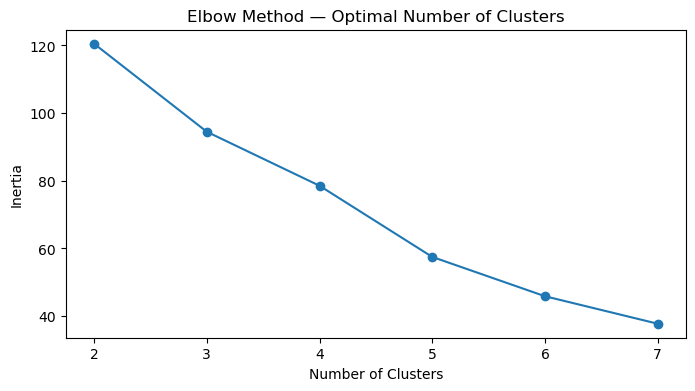

   cluster  num_traders       avg_pnl  avg_win_rate  avg_trades      avg_size  \
0        0            1 -1.676211e+05      0.382743     4601.00   2204.685531   
1        1           14  1.425208e+05      0.324440     5034.50   6892.867195   
2        2            5  1.272056e+06      0.398750    18432.60  11889.745422   
3        3           12  1.757507e+05      0.498279     3664.75   2841.682205   

    avg_drawdown  
0 -358963.139984  
1  -40348.574911  
2  -59640.016076  
3  -11151.239420  


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [46]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

cluster_features = trader_profile[['total_pnl', 'win_rate', 'trade_count', 'avg_size_usd', 'max_drawdown']].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 8), inertias, marker='o')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.savefig('charts/elbow.png', dpi=150)
plt.show()

km = KMeans(n_clusters=4, random_state=42, n_init=10)
trader_profile['cluster'] = km.fit_predict(X_scaled)

cluster_summary = trader_profile.groupby('cluster').agg(
    num_traders  = ('Account', 'count'),
    avg_pnl      = ('total_pnl', 'mean'),
    avg_win_rate = ('win_rate', 'mean'),
    avg_trades   = ('trade_count', 'mean'),
    avg_size     = ('avg_size_usd', 'mean'),
    avg_drawdown = ('max_drawdown', 'mean')
).reset_index()

print(cluster_summary)

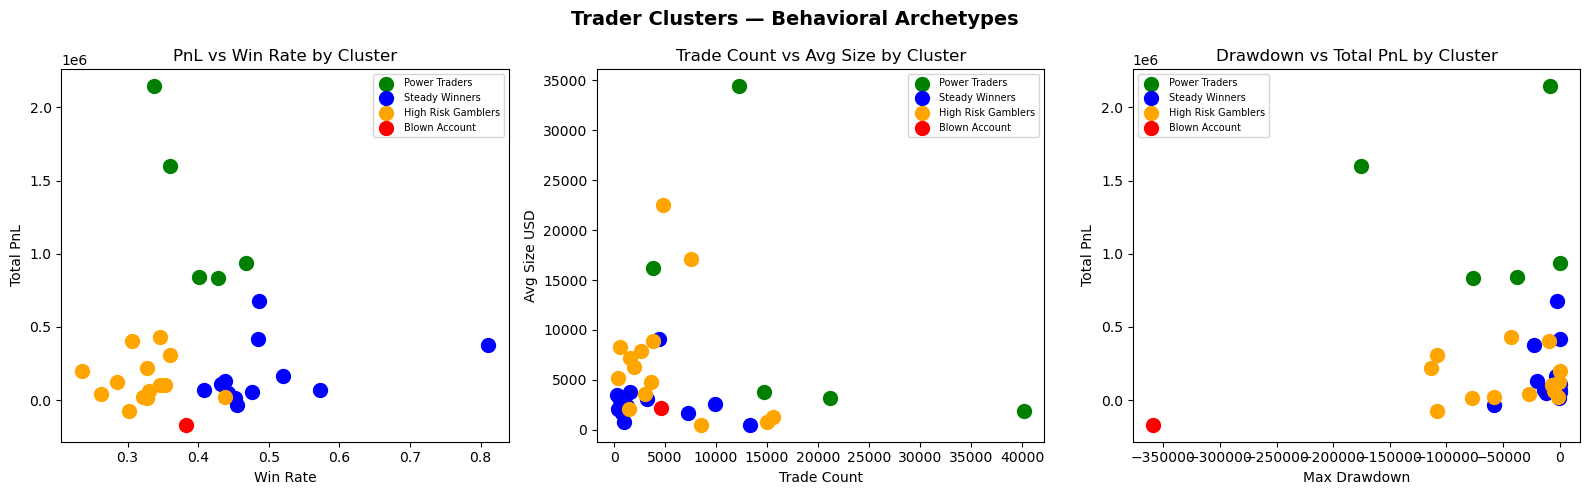

Cluster chart saved!


In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Trader Clusters — Behavioral Archetypes', fontsize=14, fontweight='bold')

colors = {0: 'red', 1: 'orange', 2: 'green', 3: 'blue'}
labels = {0: 'Blown Account', 1: 'High Risk Gamblers', 2: 'Power Traders', 3: 'Steady Winners'}

# Chart 1: PnL vs Win Rate
for c in trader_profile['cluster'].unique():
    subset = trader_profile[trader_profile['cluster'] == c]
    axes[0].scatter(subset['win_rate'], subset['total_pnl'],
                   color=colors[c], label=labels[c], s=100)
axes[0].set_title('PnL vs Win Rate by Cluster')
axes[0].set_xlabel('Win Rate')
axes[0].set_ylabel('Total PnL')
axes[0].legend(fontsize=7)

# Chart 2: Trade Count vs Avg Size
for c in trader_profile['cluster'].unique():
    subset = trader_profile[trader_profile['cluster'] == c]
    axes[1].scatter(subset['trade_count'], subset['avg_size_usd'],
                   color=colors[c], label=labels[c], s=100)
axes[1].set_title('Trade Count vs Avg Size by Cluster')
axes[1].set_xlabel('Trade Count')
axes[1].set_ylabel('Avg Size USD')
axes[1].legend(fontsize=7)

# Chart 3: Drawdown vs Total PnL
for c in trader_profile['cluster'].unique():
    subset = trader_profile[trader_profile['cluster'] == c]
    axes[2].scatter(subset['max_drawdown'], subset['total_pnl'],
                   color=colors[c], label=labels[c], s=100)
axes[2].set_title('Drawdown vs Total PnL by Cluster')
axes[2].set_xlabel('Max Drawdown')
axes[2].set_ylabel('Total PnL')
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig('charts/clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cluster chart saved!")

## Part C — Strategy Recommendations

### Strategy 1: Sentiment-Aware Sizing by Trader Type
- **Large position traders** perform better on Fear days ($111 avg PnL vs $86 on Greed)
  → During Fear days, large traders should maintain or increase position sizes
- **Mid size traders** perform 2.8x better on Greed days ($105 vs $38)
  → Mid traders should increase activity on Greed days and reduce on Fear days

### Strategy 2: Follow the Steady Winners Playbook
- Cluster 3 (Steady Winners) have the highest win rate (50%) and lowest drawdown (-$11K)
- They trade less frequently (3,664 trades) with smaller sizes ($2.8K)
- Rule: Prioritize win rate over trade frequency. 
  Cap daily trades, avoid oversizing — consistency beats aggression

### Key Finding
Market sentiment (Fear/Greed) directly predicts only 0.6% of profitability.
A trader's own behavior and consistency matters 73% more than market conditions.

## Project Summary

### Methodology
- Merged 211,224 Hyperliquid trades with Bitcoin Fear/Greed sentiment index by date
- Engineered per-trader metrics: PnL, win rate, drawdown, trade frequency, position size
- Segmented traders by frequency, size, and performance
- Built Random Forest classifier (95% accuracy) to predict daily profitability
- Applied K-Means clustering to identify 4 behavioral archetypes

### Key Insights
1. Traders are 2.3x more active on Fear days (793 trades/day vs 341 on Greed)
2. Greed days produce more consistent profits (median $245 vs $122 on Fear days)
3. Sentiment has only 0.6% predictive power — trader's own win rate drives 73% of outcomes
4. Large position traders are contrarian — they profit MORE on Fear days
5. Steady Winners (Cluster 3) achieve best risk-adjusted returns with fewer, smaller trades

### Strategy Recommendations
1. Large traders → maintain size on Fear days
2. Mid traders → increase activity on Greed days
3. All traders → prioritize win rate consistency over trade frequency